In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM ,Dropout,SimpleRNN

In [29]:
from google.colab import files

uploaded = files.upload()

Saving Google_Stock_Price.csv to Google_Stock_Price (1).csv


In [30]:
#2. Load Dataset
df = pd.read_csv("Google_Stock_Price.csv", thousands=',')
df.head()
df.describe()

,Price,Adj Close,Close,High,Low,Open,Volume
count,1260,1259,1259,1259,1259,1259,1259
unique,1260,1240,1236,1224,1229,1221,1252
top,2024-12-31 00:00:00+00:00,105.5872421,105.9700012,138,128.9600067,138.5,22288000
freq,1,3,3,3,2,3,3


In [31]:
df.tail()

,Price,Adj Close,Close,High,Low,Open,Volume
1255,2024-12-24 00:00:00+00:00,196.1100006,196.1100006,196.1100006,193.7799988,194.8399963,10403300
1256,2024-12-26 00:00:00+00:00,195.6000061,195.6000061,196.75,194.3800049,195.1499939,12046600
1257,2024-12-27 00:00:00+00:00,192.7599945,192.7599945,195.3200073,190.6499939,194.9499969,18891400
1258,2024-12-30 00:00:00+00:00,191.2400055,191.2400055,192.5500031,189.1199951,189.8000031,14264700
1259,2024-12-31 00:00:00+00:00,189.3000031,189.3000031,191.9600067,188.5099945,191.0800018,17466900


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1260 entries, 0 to 1259
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1260 non-null   object
 1   Adj Close  1259 non-null   object
 2   Close      1259 non-null   object
 3   High       1259 non-null   object
 4   Low        1259 non-null   object
 5   Open       1259 non-null   object
 6   Volume     1259 non-null   object
dtypes: object(7)
memory usage: 69.0+ KB


In [33]:
df.isnull().sum()

,0
Price,0
Adj Close,1
Close,1
High,1
Low,1
Open,1
Volume,1


In [34]:
X=df['Open'].values.reshape(-1,1)

In [35]:
X

array([['GOOGL'],
       [nan],
       ['67.42050171'],
       ...,
       ['194.9499969'],
       ['189.8000031'],
       ['191.0800018']], dtype=object)

In [36]:
scaler = MinMaxScaler(feature_range=(0,1))
# Clean non-numeric values like 'GOOGL' / NaN from Open column, then scale
data = pd.to_numeric(df['Open'], errors='coerce').dropna().values.reshape(-1, 1)
data_scaled = scaler.fit_transform(data)


In [37]:
train_size = int(len(data_scaled) * 0.8)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [38]:
def create_dataset(dataset):
    X = []
    y = []

    for i in range(60, len(dataset)):
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

In [39]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [40]:
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0416
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0019
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0011
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 7.4321e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 6.2148e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 5.5135e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 6.1546e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 5.3708e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 5.0994e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 4.5381e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 4.6808e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.0929e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 3.9001e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 3.8329e-04
Epoch 15/20
30/30 ━━━━━━━━━

In [42]:
predicted = model.predict(X_test)

predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 


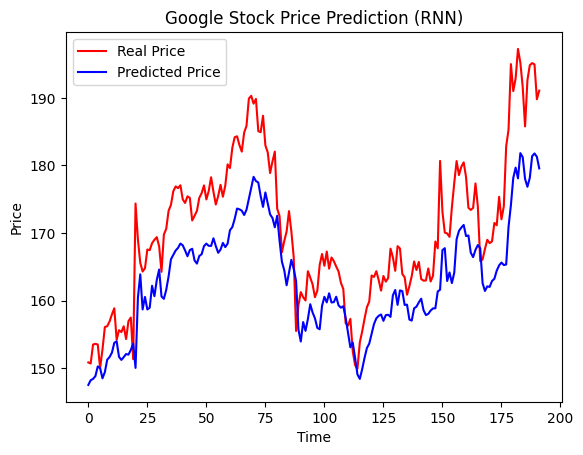

In [43]:
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()